# Pose predictors

## File Handling
To run predictions a `RobotEnvironment` object and a `HeadsetData` object is needed, those can be loaded from folders or created.

### Creation of RobotEnvironment and HeadsetData
Those 2 datatypes can be created from an GatheredRobotData object and a .vrs file respectively.

In [1]:
%load_ext autoreload
%autoreload 2
print(__debug__)
from headset_data import *
from robot_environment import *

True
Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
robot_data_folder_location = "/home/wmarx/AR-Headset-Localization-in-Robot-Scanned-Workspaces-A-Benchmark-Pipeline/datasets/r7_small_aruco4"
vrs_file_location = "/home/wmarx/AR-Headset-Localization-in-Robot-Scanned-Workspaces-A-Benchmark-Pipeline/datasets/r7_small_aruco4_20fps_close.vrs"


robot_data = GatheredRobotData.from_folder(robot_data_folder_location)
robot_env = RobotEnvironment.from_gathered_robot_data(
        robot_data = robot_data,
        number_of_sampled_datapoints=10,
        only_sample_robot_datapoints_w_marker_estimates = True,
        markers_use_advanced_removal=True,
        est3d_xyz_image_gen_config = XYZImageGenerationConfig(),
        est3d_xyz_icp_config=ICPAlignmentConfig()
)

labeled_headset_data = create_robot_bound_headset_data(
        headset_data = HeadsetData.from_vrs_file(vrs_file_location),
        robot_data = robot_data
)

visualize_loaded_data = True

if visualize_loaded_data:
    visualize_robot_camera_environment_combo(robot_env=robot_env, headset_data=labeled_headset_data)


length of chosen indices 10
Generating point cloud...
Loading pretrained dinov2_vitg14 from torch hub


Using cache found in /home/wmarx/.cache/torch/hub/facebookresearch_dinov2_main


image shape before processing: (10, 720, 720, 3)
xyz images shape: (10, 518, 518, 3)
aligning pointclouds using ICP


100%|██████████| 9/9 [00:48<00:00,  5.35s/it]
[ProgressLogger][INFO]: 2026-06-11 13:43:03: Opening /home/wmarx/AR-Headset-Localization-in-Robot-Scanned-Workspaces-A-Benchmark-Pipeline/datasets/r7_small_aruco4_20fps_close.vrs...
[TelemetryLogger][INFO]: RecordFileReader::doOpenFile, diskfile: success, 29224928
[VRSIndexRecord][WARNING]: 1 record(s) not sorted properly. Sorting index.
[MultiRecordFileReader][DEBUG]: Opened file '/home/wmarx/AR-Headset-Localization-in-Robot-Scanned-Workspaces-A-Benchmark-Pipeline/datasets/r7_small_aruco4_20fps_close.vrs' and assigned to reader #0
[VrsDataProvider][INFO]: streamId 214-1/camera-rgb activated
[VrsDataProvider][INFO]: streamId 247-1/baro0 activated
[VrsDataProvider][INFO]: streamId 281-1/gps activated
[VrsDataProvider][INFO]: streamId 282-1/wps activated
[VrsDataProvider][INFO]: streamId 283-1/bluetooth activated
[VrsDataProvider][INFO]: Utc stream found: 285-1
[VrsDataProvider][INFO]: Fail to activate streamId 286-1
[VrsDataProvider][INFO]: 

## Testing Predictors

In [3]:
from predictor_grader import *
from pose_pred_points import *
from pose_pred_points_lines import *

### Creating Predictors
Now an `PosePredictor` can be created. An `PosePredictor` instance is build upon an `RobotEnvironment` instance and can predict positions from headset-images.

In [4]:
predictor = LinePredictor(
    cam2_intrinsic_mtx=labeled_headset_data.intrinsic_cam_mtx,
    cam1_bgr_images=robot_env.robot_bgr_images,
    cam1_xyz_images=robot_env.robot_xyz_images,
    extract_and_match_wrapper_config=ExtractAndMatchWrapperConfig(
        extract_and_match=ExtractAndLightGlue(
            extractor="SuperPoint"
        ),
        ransac_config=pose_estimation_ransaac_config_less_precise,
    ),
    line_fitting_3d_config=LineFitting3dConfig(use_ransac=False),
    pnpl_optimisation_conf=PnPLOptimizerConfig(lm_max_steps=10000,line_relevance=1.0),
    cam2_lsd_diagonal_size=None,
    debug_visualize_line_cleanup=False, 
    debug_visualize_pnpl=False
)

### Grading the Performance of an Initialised Predictor:

In [7]:
init_predictor_grade = PredictionOnDataset(
    predictor = predictor,
    headset_data = labeled_headset_data,
    number_retry = 1
)
init_predictor_grade.print_summary()


visualize_prediction = True
if visualize_prediction:
    init_predictor_grade.visualize_predictions(
        robot_env=robot_env,
        show_label=False
    )

  0%|          | 0/90 [00:00<?, ?it/s]

100%|██████████| 90/90 [00:15<00:00,  5.76it/s]


Success rate: 0.9555555555555556 for 90 predictions
Avg. time per prediction: 177.07111714624386ms
est_base_t_cam subcomponent times:

Image 2 LSD + cleanup                    59.297 ms


Avg. error: 308.9mm and 28.9°
Median. error: 250.6mm and 26.1°
ATE RMSE: 372.1mm and 34.0°
RTE RMSE: 420.3mm and 35.0°


In [11]:
# Creation of the Predictors
light_glue = ExtractAndLightGlue()


point_based = GradablePosePredictor(
    creator=OnlyPointsPredictor.get_creation_function(
        cam2_intrinsic_mtx=labeled_headset_data.intrinsic_cam_mtx,
        extract_and_match_wrapper_config=ExtractAndMatchWrapperConfig(
            rotation_augmentations=[Rotate180Deg],
            extract_and_match=light_glue,
            ransac_config=pose_estimation_ransaac_config_precise,
        )
    ),
    name="only points"
)

line_predictor = GradablePosePredictor(
    creator=LinePredictor.get_creation_function(
        cam2_intrinsic_mtx=labeled_headset_data.intrinsic_cam_mtx,
        extract_and_match_wrapper_config=ExtractAndMatchWrapperConfig(
            extract_and_match=ExtractAndLightGlue(
                extractor="SuperPoint"
            ),
            ransac_config=pose_estimation_ransaac_config_less_precise,
        ),
        line_fitting_3d_config=LineFitting3dConfig(use_ransac=False),
        pnpl_optimisation_conf=PnPLOptimizerConfig(lm_max_steps=10000,line_relevance=0.3),
        cam2_lsd_diagonal_size=1000,
        debug_visualize_line_cleanup=False, 
        debug_visualize_pnpl=False 
    ),
    name="lines"
)

Now those can be used to create a grader object for multiple `PosePredictor` variants.

In [12]:
# Initialising the grader:
grader = NPredictors1DatasetGrader(
    gradable_pose_predictors=[point_based, line_predictor],
    headset_data = labeled_headset_data,
    robot_env = robot_env,
)

100%|██████████| 90/90 [00:09<00:00,  9.71it/s]


name                           success ratio %      T/frame [ms]    avg t_err [mm]  avg r_err [deg] med t_err [mm]  med r_err [deg]

only points                    95.56                60              108.7           7.6            90.9            5.9            
lines                          95.56                105             95.1            6.3            83.3            4.9            
rest: [0.14682021 0.12872461]


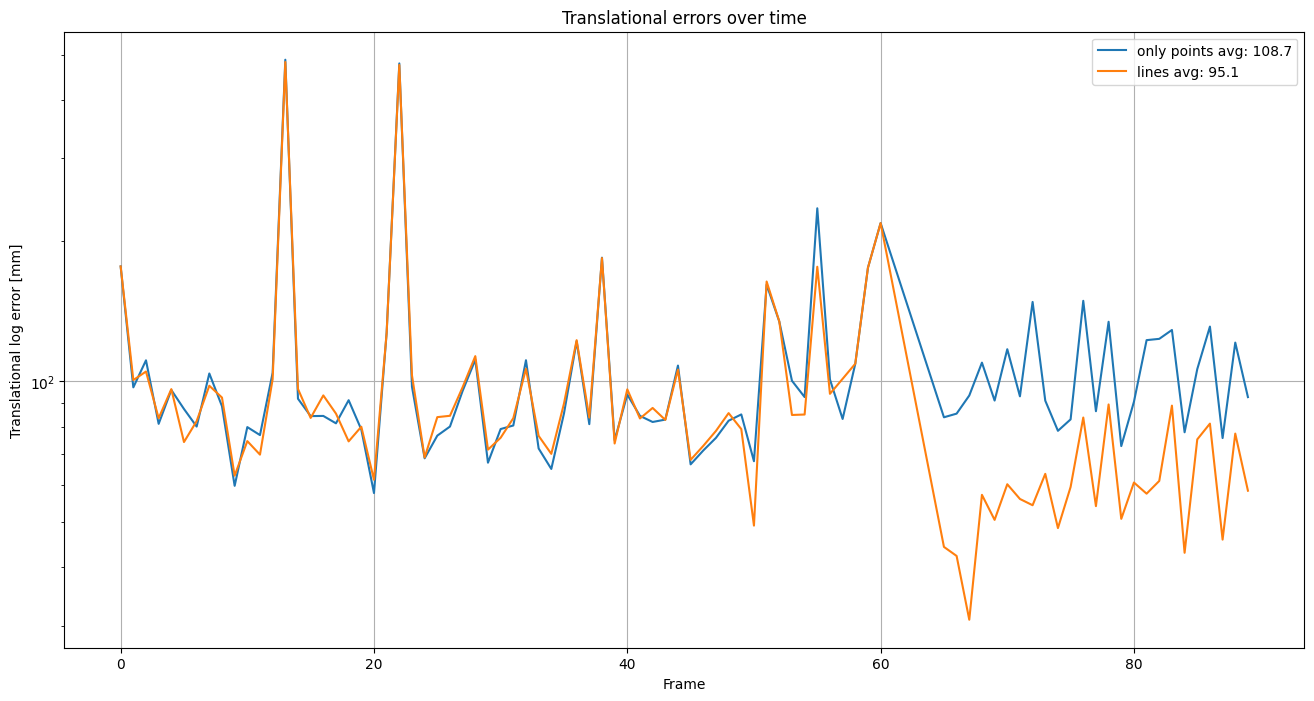

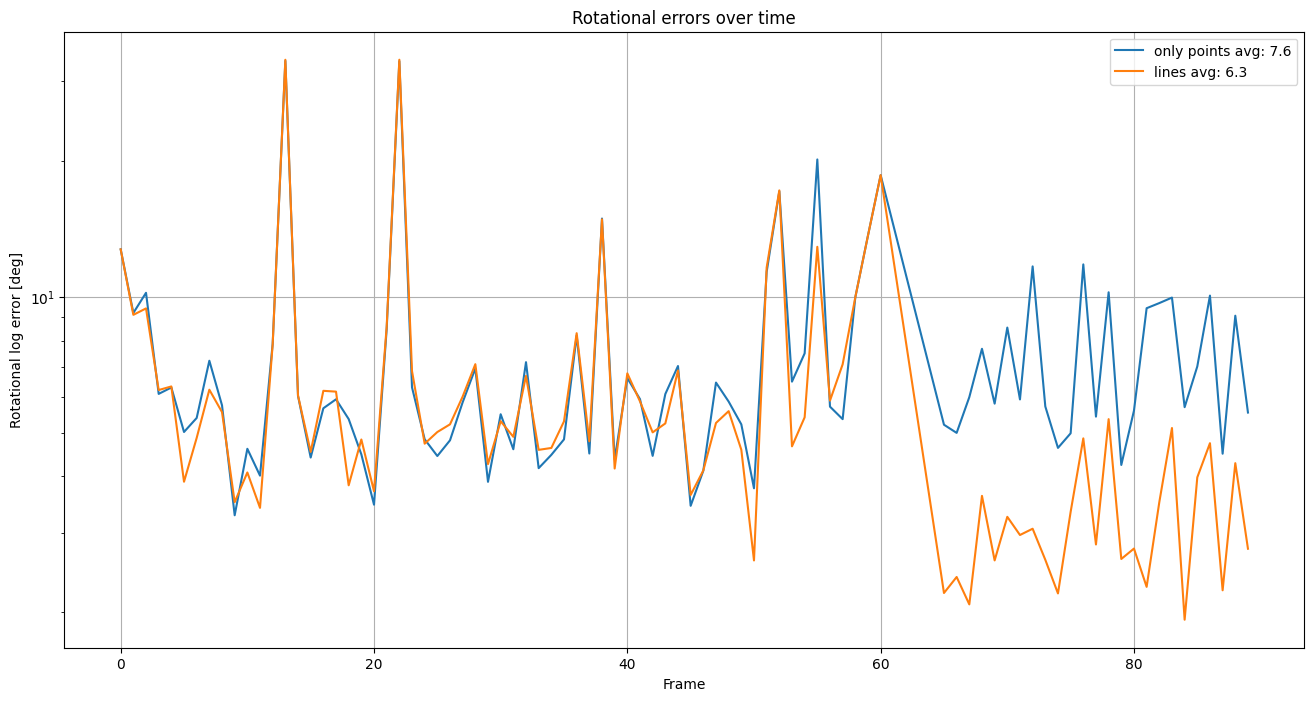

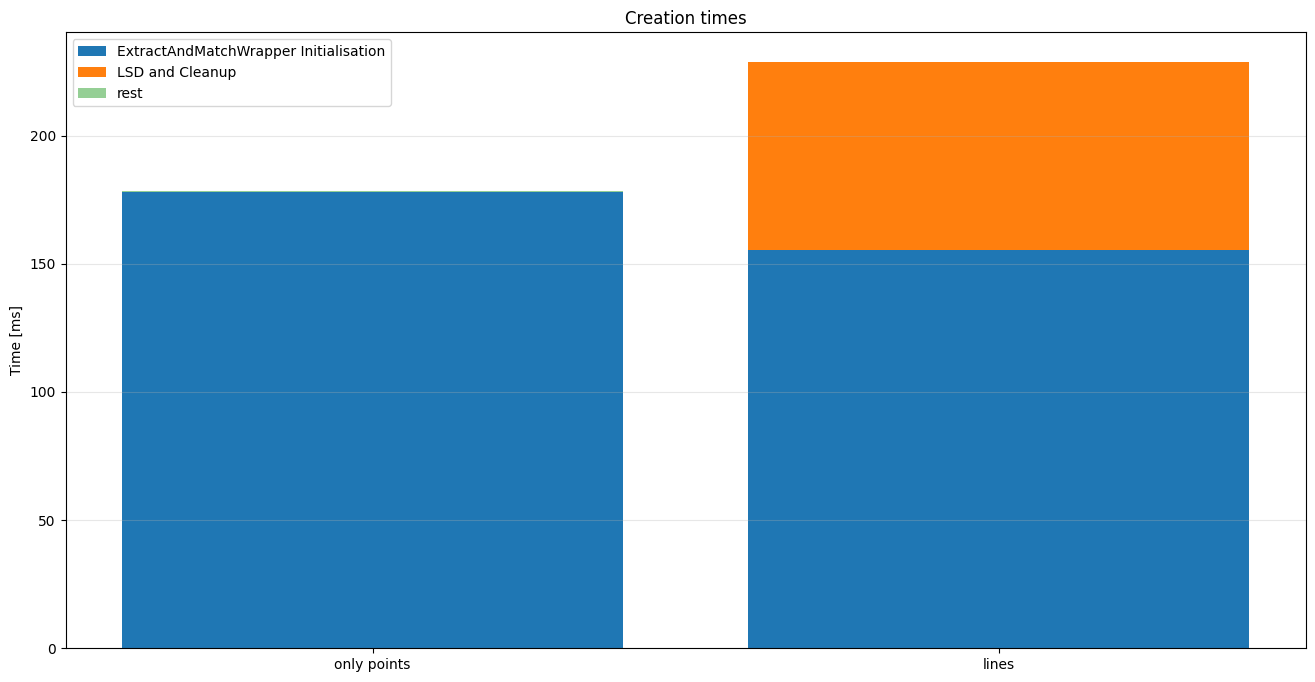

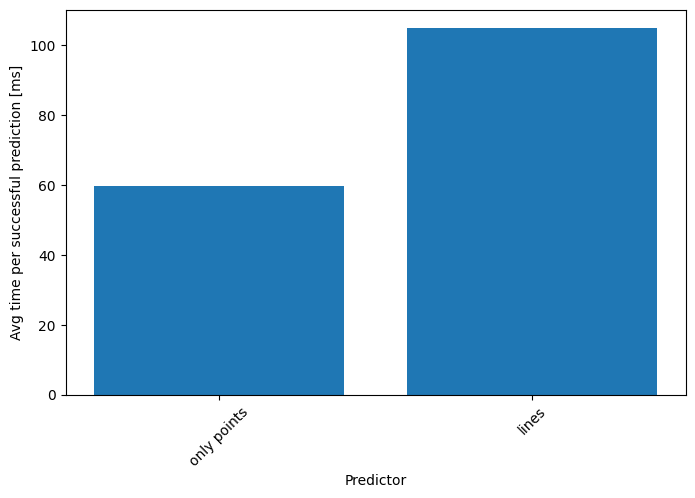

In [13]:
visualize_trajectories_3d = False
if visualize_trajectories_3d:
    grader.visualize_predictions_3d()

grader.print_summary()

fig1, ax1 = plt.subplots(1, 1, figsize = (16, 8))
grader.plot_translational_errors(ax1)

fig2, ax2 = plt.subplots(1, 1, figsize = (16, 8))
grader.plot_rotational_errors(ax2)

fig3, ax3 = plt.subplots(1, 1, figsize = (16, 8))
grader.plot_creation_times(ax3)

fig4, ax4 = plt.subplots(1, 1, figsize = (8, 5))
grader.plot_successful_frame_prediction_times(ax4)


plt.show()

### Video visualisation

In [17]:
video_predictor = LinePredictor(
    cam2_intrinsic_mtx=labeled_headset_data.intrinsic_cam_mtx,
    cam1_bgr_images=robot_env.robot_bgr_images,
    cam1_xyz_images=robot_env.robot_xyz_images,
    extract_and_match_wrapper_config=ExtractAndMatchWrapperConfig(
        extract_and_match=ExtractAndLightGlue(
            extractor="SuperPoint"
        ),
        ransac_config=pose_estimation_ransaac_config_less_precise,
    ),
    line_fitting_3d_config=LineFitting3dConfig(use_ransac=False),
    pnpl_optimisation_conf=PnPLOptimizerConfig(lm_max_steps=10000,line_relevance=0.3),
    cam2_lsd_diagonal_size=None,
    debug_visualize_line_cleanup=False, 
    debug_visualize_pnpl=False
)

init_predictor_grade = PredictionOnDataset(
    predictor = video_predictor,
    headset_data = labeled_headset_data,
    number_retry = 1,
    vid_gen=VideoGenerator(fps=20)
)
init_predictor_grade.print_summary()

 26%|██▌       | 23/90 [00:04<00:12,  5.36it/s]